---
title: "Lecture 8: Conditioning, Bayes' Rule"
author: "Jamie Haddock"
format:
    revealjs:
        output-file: Lecture8_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
        html-math-method: katex
        slide-level: 3
    html:
        code-fold: true
        embed-resources: true
        output-file: Lecture8
        code-links:
          - text: "Open in Colab"
            href: "https://colab.research.google.com/github/jamiehadd/Math-151-Probability/blob/main/08_conditioning-bayes-rule.ipynb"
            icon: "laptop"
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        output-file: Lecture8
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: python3
colab:
  gh-user: "jamiehadd"
  gh-repo: "Math-151-Probability"
filters:
  - input/remove-pause.lua
  - colab
execute:
  echo: true
  eval: true
---

In [ ]:
# | echo: false

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, integrate

rng = np.random.default_rng(151)
plt.rcParams["figure.figsize"] = (6, 4)

# Conditioning

## Conditioning a Random Variable on an Event

::: {.callout-note}
## Definition: conditional PDF given an event

The conditional PDF $f_{X\mid A}$ of a continuous random variable $X$, given an event $A$ with $P(A) > 0$ satisfies $$P(X \in B \mid A) = \int_{B} f_{X \mid A}(x) dx.$$


If $A \subset \mathbb{R}$ with $P(X \in A) > 0$, then

$$
f_{X \mid \{X \in A\}}(x) = \frac{f_X(x)}{P(X \in A)} \quad \text{for } x \in A,
$$

and $f_{X \mid \{X \in A\}}(x) = 0$ otherwise.

:::

. . .

Going from $f_X$ to $f_{X \mid \{X \in A\}}$ zeroes
out the mass/density outside $A$, and rescales what remains so it once
again integrates (or sums) to $1$.

---

![](figs/cond_pdf.jpeg)

---

### Example: Memorylessness of Exponential RV

Let $T \sim \text{Exponential}(\lambda)$ model a lightbulb's lifetime, and
condition on the event $A = \{T > s\}$: the bulb has already survived $s$
hours.

. . .

$$
P(A) = P(T > s) = \int_s^\infty \lambda e^{-\lambda t}\,dt = e^{-\lambda s}.
$$

. . .

For $t \ge s$,
$$
f_{T \mid T>s}(t) = \frac{f_T(t)}{P(T>s)} = \frac{\lambda e^{-\lambda t}}{e^{-\lambda s}} = \lambda e^{-\lambda (t - s)}.
$$

::: {.callout-tip}
## Lightbulb interpretation

Substituting $\tau = t - s$ (additional lifetime past time $s$), the density
of $\tau$ given $T > s$ is $\lambda e^{-\lambda \tau}$ -- still an Exponential$(\lambda)$ density. A bulb that has already burned for
$s$ hours is, from this moment on, statistically identical to a brand-new
bulb. 
:::

---

### Law of Total Probability

Just as a PMF can be decomposed over a partition, so can the PDF of a
random variable: 

::: {.callout-note}
## Theorem: law of total probability, RV form

If $A_1, \dots, A_n$ partition the sample space
with $P(A_i) > 0$ for all $i$, then
$$
f_X(x) = \sum_{i=1}^n P(A_i)\, f_{X \mid A_i}(x).
$$
:::

. . .

---

### Example: A Population Mixture of Two Gaussians

A population's heights come from one of two subpopulations, each with its own Gaussian distribution:
$$
X \mid M \sim N(70, 3^2), \qquad X \mid F \sim N(62, 2.5^2).
$$

. . .

By the law of total probability (with the two-event partition $\{M, F\}$):
$$
f_X(x) = P(M)\, f_{X\mid M}(x) + P(F)\, f_{X\mid F}(x) = \tfrac12\, \phi_{70,3}(x) + \tfrac12\, \phi_{62,2.5}(x).
$$

::: {.callout-warning}
## A mixture of Gaussians is *not*, in general, Gaussian

$f_X$ above is not itself of the form $\phi_{\mu,\sigma}$ for any $\mu,\sigma$ — averaging two Gaussian densities does not give a Gaussian density. Second, bimodality isn't automatic: if the two subpopulation means are close relative to their spreads (e.g. $70$ vs. $64$ with the same $3$ and $2.5$), the same recipe produces a single-peaked $f_X$.  Learning these Gaussian components is known as *Gaussian mixture models* in statistical and machine learning.
:::

---

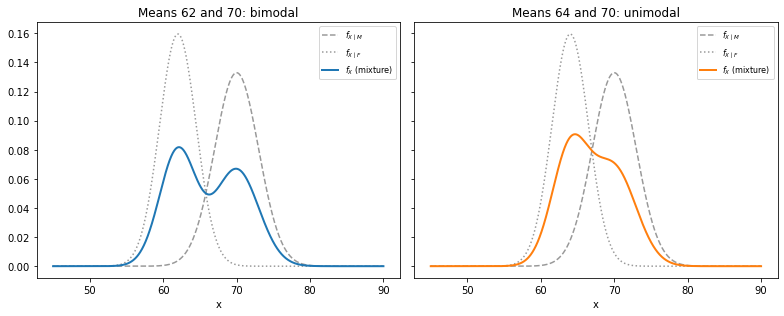

In [5]:
# Gaussian mixture: bimodal vs. unimodal, depending on separation
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy import integrate

def mixture_pdf(x, p, mu1, s1, mu2, s2):
    return p * norm.pdf(x, mu1, s1) + (1 - p) * norm.pdf(x, mu2, s2)

# Case 1: well-separated means -> bimodal
p, mu1, s1, mu2, s2 = 0.5, 70, 3, 62, 2.5

# Case 2: same spreads, closer means -> unimodal
mu1_close, mu2_close = 70, 64

xs = np.linspace(45, 90, 2000)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

# --- Panel 1: bimodal case ---
axes[0].plot(xs, norm.pdf(xs, mu1, s1), color="0.6", ls="--", label=r"$f_{X\mid M}$")
axes[0].plot(xs, norm.pdf(xs, mu2, s2), color="0.6", ls=":", label=r"$f_{X\mid F}$")
axes[0].plot(xs, mixture_pdf(xs, p, mu1, s1, mu2, s2), color="C0", lw=2, label=r"$f_X$ (mixture)")
axes[0].set_title(f"Means {mu2} and {mu1}: bimodal")
axes[0].legend(fontsize=8)
axes[0].set_xlabel("x")

# --- Panel 2: unimodal case ---
axes[1].plot(xs, norm.pdf(xs, mu1_close, s1), color="0.6", ls="--", label=r"$f_{X\mid M}$")
axes[1].plot(xs, norm.pdf(xs, mu2_close, s2), color="0.6", ls=":", label=r"$f_{X\mid F}$")
axes[1].plot(xs, mixture_pdf(xs, p, mu1_close, s1, mu2_close, s2), color="C1", lw=2, label=r"$f_X$ (mixture)")
axes[1].set_title(f"Means {mu2_close} and {mu1_close}: unimodal")
axes[1].legend(fontsize=8)
axes[1].set_xlabel("x")

plt.tight_layout()
plt.show()

# --- Numerical checks ---
# 1) mixture integrates to 1
check1 = integrate.quad(lambda x: mixture_pdf(x, p, mu1, s1, mu2, s2), -np.inf, np.inf)[0]
check2 = integrate.quad(lambda x: mixture_pdf(x, p, mu1_close, s1, mu2_close, s2), -np.inf, np.inf)[0]


# 2) count local maxima (peaks) to confirm bimodal vs. unimodal numerically
def count_modes(p, mu1, s1, mu2, s2, lo=45, hi=90, n=4000):
    grid = np.linspace(lo, hi, n)
    vals = mixture_pdf(grid, p, mu1, s1, mu2, s2)
    d = np.diff(vals)
    peaks = grid[1:-1][(d[:-1] > 0) & (d[1:] < 0)]
    return peaks


## Conditioning One RV on Another

::: {.callout-note}
## Definition: conditional PDF given another RV

For jointly continuous $X, Y$ with joint PDF $f_{X,Y}(x,y)$ and $y$ with $f_Y(y) > 0$,
$$
f_{X \mid Y}(x \mid y) \;=\; \frac{f_{X,Y}(x,y)}{f_Y(y)}.
$$
:::

. . .

For each fixed $y$, we take the *slice* of the joint
density along $Y=y$ and rescale it (divide by $f_Y(y)$) so it integrates to
$1$ in $x$.

---

### Example: Dartboard

Let $(X, Y)$ be uniform on the unit disk (a dart thrown uniformly at a
circular board of radius 1):
$$
f_{X,Y}(x,y) = \begin{cases} \dfrac{1}{\pi}, & x^2+y^2 \le 1,\\[2pt] 0, & \text{otherwise.}\end{cases}
$$

Recall that this has a *non-uniform* marginal,
$f_X(x) = \dfrac{2\sqrt{1-x^2}}{\pi}$ for $|x|\le 1$.

. . .

For $|x| < 1$, the conditional PDF is
$$
f_{Y\mid X}(y \mid x) = \frac{f_{X,Y}(x,y)}{f_X(x)}
= \frac{1/\pi}{2\sqrt{1-x^2}/\pi}
= \frac{1}{2\sqrt{1-x^2}}, \qquad |y| < \sqrt{1-x^2}.
$$

---

::: {.callout-tip}
## Physical interpretation

Given only the dart's horizontal coordinate $X=x$, the possible vertical
landing spots are the **chord** of the disk at that $x$ -- and $Y$ is
*uniform* over that chord, even though the joint density was uniform over
the whole disk. Conditioning "slices" the flat joint density and renormalizes
the slice; the slice itself is still flat, so it's uniform on its (shorter)
interval.
:::

## Conditional Expectation

::: {.callout-note}
## Definition

Let $X$ and $Y$ be jointly continous random variables, and let $A$ be an event with $P(A) > 0$, then the conditional expectation is
$$
E[X \mid A] = \int_{-\infty}^{\infty} x\, f_{X\mid A}(x)\,dx,
$$
$$
E[X \mid Y=y] = \int_{-\infty}^{\infty} x\, f_{X\mid Y}(x\mid y)\,dx.
$$
:::

. . .

::: {.callout-tip}
## LOTUS still holds

$$
E[g(X) \mid Y=y] = \int g(x)\, f_{X\mid Y}(x\mid y)\,dx.
$$
Conditioning just replaces the unconditional (marginal) distribution with the
conditional one everywhere in the LOTUS formula.
:::

---

::: {.callout-note}
## Theorem: total expectation theorem

Let $A_1, \cdots, A_n$ form a partition of the sample sapce, and assume that $P(A_i) > 0$ for all $i$.  Then, 
$$\;E[X] = \sum_i P(A_i)\, E[X \mid A_i].$$

Similarly, $$\;E[X] = E\big[E[X \mid Y]\big] = \displaystyle\int_{-\infty}^{\infty} E[X\mid Y=y]\, f_Y(y)\, dy.$$
:::

---

### Example: Dartboard, continued

By the symmetry $f_{Y\mid X}(y\mid x) = f_{Y\mid X}(-y\mid x)$ established
previously,
$$
E[Y \mid X=x] = \int_{-\sqrt{1-x^2}}^{\sqrt{1-x^2}} y \cdot \frac{1}{2\sqrt{1-x^2}}\, dy = 0 \quad \text{for every } x.
$$

. . .

By the total expectation theorem (RV form),
$$
E[Y] = E\big[E[Y\mid X]\big] = \int_{-1}^1 0 \cdot f_X(x)\,dx = 0,
$$
consistent with computing $E[Y]$ directly from the (also symmetric) marginal
$f_Y$.

## Independence

::: {.callout-note}
## Definition

Continuous $X, Y$ are **independent** if
$$
f_{X,Y}(x,y) = f_X(x)\, f_Y(y) \quad \text{for all } x, y,
$$
equivalently $f_{X\mid Y}(x\mid y) = f_X(x)$ whenever $f_Y(y) > 0$.
:::

. . .

::: {.callout-tip}
## Two facts carried over from discrete case

**Product rule for expectation.** If $X, Y$ independent, $E[XY] = E[X]\,E[Y]$
(the joint density factors, so the double integral in two-variable LOTUS
splits into a product of two single integrals).

**Linearity of variance.** If $X, Y$ independent,
$\mathrm{Var}(X+Y) = \mathrm{Var}(X) + \mathrm{Var}(Y)$.
:::

---

### Example: Joint PDF of Independent Gaussian RVs

If $X_1, \dots, X_n$ are independent with $X_i \sim N(\mu_i, \sigma_i^2)$,
their joint density is simply the product of the marginals:
$$
\begin{aligned}
f(x_1,\dots,x_n) &= \prod_{i=1}^n \frac{1}{\sqrt{2\pi}\sigma_i} \exp\!\left(-\frac{(x_i-\mu_i)^2}{2\sigma_i^2}\right) 
\\&= \frac{1}{(2\pi)^{n/2} |\Sigma|^{1/2}} \exp\!\left(-\tfrac{1}{2}(\mathbf{x}-\boldsymbol\mu)^\top \Sigma^{-1} (\mathbf{x}-\boldsymbol\mu)\right),
\end{aligned}
$$
where $\Sigma = \mathrm{diag}(\sigma_1^2, \dots, \sigma_n^2)$.


. . .

::: {.callout-note}
## Definition: isotropic

If, further, every $\sigma_i = \sigma$, then $\Sigma = \sigma^2 I$ and $f$
depends on $\mathbf x$ only through $\|\mathbf x - \boldsymbol\mu\|^2$ --
the density looks the **same in every direction**. Such a distribution is
called **isotropic**. Its level sets (contours of equal density) are circles
(or spheres, in higher dimension) rather than general ellipses.
:::

---

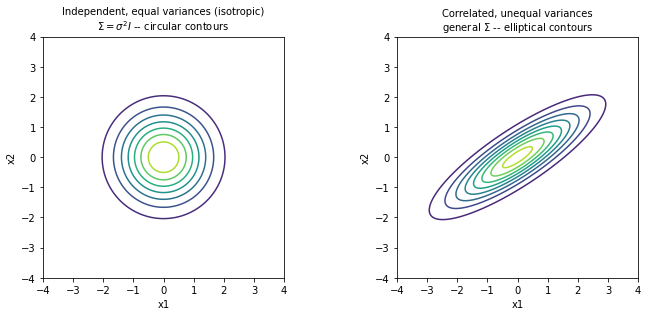

In [4]:
# independent isotropic Gaussian (circular contours) vs. a general
# (correlated / non-isotropic) Gaussian (elliptical contours) -- L7 teaser, resolved
from scipy.stats import multivariate_normal

x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

mu = [0, 0]
Sigma_isotropic = [[1.0, 0.0], [0.0, 1.0]]          # sigma^2 I
Sigma_general    = [[2.0, 1.2], [1.2, 1.0]]          # correlated, non-isotropic

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, Sigma, title in zip(
    axes, [Sigma_isotropic, Sigma_general],
    ["Independent, equal variances (isotropic)\n" + r"$\Sigma=\sigma^2 I$ -- circular contours",
     "Correlated, unequal variances\n" + r"general $\Sigma$ -- elliptical contours"]):
    rv = multivariate_normal(mu, Sigma)
    ax.contour(X, Y, rv.pdf(pos), levels=8, cmap="viridis")
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")

plt.tight_layout()
plt.show()

# Bayes' Rule

## Inference

In inference, we have some unknown quantity $\Theta$ (a parameter, a
hypothesis, a signal -- anything unobserved) and a **prior** distribution
for it that reflects our belief before seeing any data. We then observe data
$X$, whose distribution depends on $\Theta$. Bayes' rule produces the **posterior** distribution of $\Theta$ given the data we
actually observed.

. . .

$$
\underbrace{f_\Theta(\theta)}_{\text{prior}} \quad\Longrightarrow\quad \text{observe } X=x \quad\Longrightarrow\quad \underbrace{f_{\Theta\mid X}(\theta \mid x)}_{\text{posterior}}
$$

. . .

$\Theta$ and $X$ can each be discrete or continuous, giving four cases. Today
we'll work through the continuous-continuous case here, then the two mixed
cases in the next two sections.

---

### Example: Lightbulb w/ Exponential Lifetime (estimating mean parameter)

An engineer doesn't know a bulb's failure rate $\lambda$ exactly, but
believes it's somewhere between $0.5$ and $2.0$ (per year), with no value
more likely than another *a priori*:
$$
\Lambda \sim \text{Uniform}(0.5,\, 2.0).
$$
She observes one bulb's lifetime $X = x$, where $X \mid \Lambda=\lambda \sim \text{Exponential}(\lambda)$.

. . .

::: {.callout-note}
## Bayes' rule, continuous-continuous case

$$
f_{\Lambda \mid X}(\lambda \mid x) = \frac{f_{X\mid\Lambda}(x\mid\lambda)\, f_\Lambda(\lambda)}{f_X(x)},
\qquad
f_X(x) = \int f_{X\mid\Lambda}(x\mid\lambda)\, f_\Lambda(\lambda)\, d\lambda.
$$
:::

---

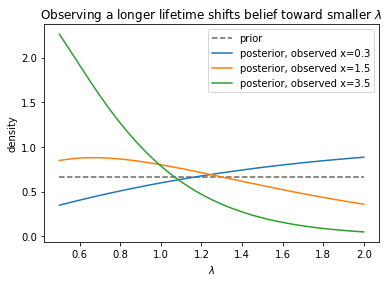

In [2]:
# lightbulb: continuous prior, continuous observation
a, b = 0.5, 2.0  # prior support

def prior(lam):
    return np.where((lam >= a) & (lam <= b), 1.0/(b-a), 0.0)

def likelihood(x, lam):
    return lam * np.exp(-lam * x)

def evidence(x):
    return integrate.quad(lambda lam: likelihood(x, lam) * prior(lam), a, b)[0]

def posterior(lam, x):
    return likelihood(x, lam) * prior(lam) / evidence(x)

lams = np.linspace(a, b, 300)

fig, ax = plt.subplots()
ax.plot(lams, prior(lams), color="0.4", ls="--", label="prior")
for x_obs, color in zip([0.3, 1.5, 3.5], ["C0", "C1", "C2"]):
    post = [posterior(l, x_obs) for l in lams]
    ax.plot(lams, post, color=color, label=f"posterior, observed x={x_obs}")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("density")
ax.legend()
ax.set_title("Observing a longer lifetime shifts belief toward smaller " + r"$\lambda$")
plt.show()


## Inference about Discrete RV

Now suppose $\Theta$ is **discrete** but the data $X$ we observe is
**continuous**.

. . .

::: {.callout-note}
## Bayes' rule

Start from the definition of a conditional PDF given an event, applied to
$A = \{\Theta = \theta\}$, together with the (RV form) law of total
probability for $f_X$:
$$
P(\Theta=\theta \mid X=x) = \frac{f_{X\mid\Theta}(x\mid\theta)\, P(\Theta=\theta)}{f_X(x)},
\qquad
f_X(x) = \sum_\theta f_{X\mid\Theta}(x\mid\theta)\, P(\Theta=\theta).
$$
:::

The denominator is computed by the Law of Total Probability from earlier in the
lecture, applied with the partition $\{\Theta=\theta\}$ over all possible
values of $\theta$.

---

### Example: Signal Detection

Recall our previous signal-detection setup: a binary signal
$S\in\{-1,+1\}$ is sent with equal prior probability, through a channel
with additive noise $N \sim N(0,\sigma^2)$ independent of $S$, so we
observe $Y = S + N$. We previously derived the *error probability* of the rule "decide
$+1$ if $Y>0$"; today we derive that rule itself, as a consequence of Bayes'
rule.

. . .

By the formula above (with $\Theta = S$, discrete; $X = Y$, continuous):
$$
P(S=+1 \mid Y=y) = \frac{\phi\!\left(\frac{y-1}{\sigma}\right) \cdot \tfrac12}
{\phi\!\left(\frac{y-1}{\sigma}\right)\tfrac12 + \phi\!\left(\frac{y+1}{\sigma}\right)\tfrac12}
= \frac{1}{1 + e^{-2y/\sigma^2}},
$$
where $\phi$ is the standard normal density.

. . .

::: {.callout-tip}
## Recovering the decision rule

$P(S=+1\mid Y=y) > \tfrac12$ exactly when $y > 0$. The rule that we evaluated failure probability for previously is the rule that picks the
**more probable** signal given the observation -- this is called the *maximum a
posteriori (MAP)* rule.
:::

## Inference Based on Discrete Observations

Suppose now $\Theta$ may be **continuous** while the data $N$ we
observe is **discrete**.

. . .

::: {.callout-note}
## Bayes' rule, continuous $\Theta$ / discrete $N$

$$
f_{\Theta \mid N}(\theta \mid n) = \frac{P(N=n\mid\Theta=\theta)\, f_\Theta(\theta)}{P(N=n)},
\qquad
P(N=n) = \int P(N=n\mid\Theta=\theta)\, f_\Theta(\theta)\, d\theta.
$$
:::


---

### Example: Estimating a Coin's Bias

A coin's probability of heads $\Theta$ is unknown; take a totally
uninformative prior $\Theta \sim \text{Uniform}(0,1)$ — every possible bias
is equally plausible before you flip. Flip it $n$ times and observe $K$ =
number of heads, where $K\mid\Theta=\theta \sim \text{Binomial}(n,\theta)$.

. . .

Plugging the Binomial likelihood and the (constant) uniform prior density $f_\Theta(\theta)=1$ into the continuous-$\Theta$/discrete-observation form of Bayes' rule from the previous slide:
$$
f_{\Theta\mid K}(\theta \mid k) = \frac{\binom{n}{k}\theta^k(1-\theta)^{n-k} \cdot 1}{P(K=k)}
\;\propto\; \theta^k (1-\theta)^{n-k}, \qquad 0 \le \theta \le 1.
$$

::: {.callout-tip}
## $\propto$

The "$\propto$" symbol means ``proportional to" and drops any $\theta$-free factor (ignoring the normalization factors since they don't depend on $\theta$).
:::

---

### The Posterior Is a Named Distribution

Normalizing means dividing by $\displaystyle\int_0^1 \theta^k(1-\theta)^{n-k}\,d\theta$, which has the closed form $\dfrac{k!\,(n-k)!}{(n+1)!}$ (a Beta-function value at integer arguments). So
$$
f_{\Theta\mid K}(\theta \mid k) = \frac{\theta^k(1-\theta)^{n-k}}{k!(n-k)!/(n+1)!}, \qquad 0 \le \theta \le 1,
$$
which is exactly the density of a $\text{Beta}(k+1,\, n-k+1)$ random variable.

---

::: {.callout-note}
## Two different point estimates from the same posterior

The **mode** of $\text{Beta}(k+1,n-k+1)$ — the value of $\theta$ that maximizes the posterior density, i.e. the *MAP estimate* — is
$$
\hat\theta_{\text{MAP}} = \frac{k}{n},
$$
exactly the naive sample proportion. The **mean** of the same distribution — the Bayes estimator under squared-error loss — is
$$
\hat\theta_{\text{mean}} = \frac{k+1}{n+2},
$$
the classical **Laplace's rule of succession** (add one hypothetical success and one hypothetical failure, then average). 
:::

---

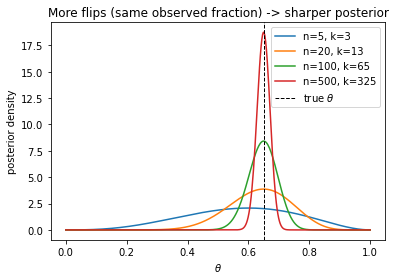

In [3]:
# coin-bias inference: posterior concentrates as n grows (same observed proportion)
theta_true = 0.65
theta_grid = np.linspace(0, 1, 400)

def unnorm_posterior(theta, n, k):
    return theta**k * (1-theta)**(n-k)

fig, ax = plt.subplots()
for n in [5, 20, 100, 500]:
    k = int(round(theta_true * n))  # keep the observed proportion k/n ~ theta_true
    up = unnorm_posterior(theta_grid, n, k)
    Z = integrate.quad(lambda t: unnorm_posterior(t, n, k), 0, 1)[0]
    ax.plot(theta_grid, up/Z, label=f"n={n}, k={k}")

ax.axvline(theta_true, color="k", lw=1, ls="--", label=r"true $\theta$")
ax.set_xlabel(r"$\theta$"); ax.set_ylabel("posterior density")
ax.legend()
ax.set_title("More flips (same observed fraction) -> sharper posterior")
plt.show()

